# Contexto, problema, objetivos e hipótesis

## Contexto

El presente proyecto utiliza el dataset **Cardiovascular Disease Dataset**, obtenido de **Kaggle**, el cual contiene aproximadamente 70.000 registros de pacientes con variables clínicas, antropométricas y de estilo de vida. Entre las variables disponibles se encuentran edad, género, altura, peso, presión arterial sistólica, presión arterial diastólica, colesterol, glucosa, tabaquismo, consumo de alcohol, actividad física y la variable objetivo `cardio`.

La variable `cardio` indica la presencia o ausencia de enfermedad cardiovascular, donde `0` representa ausencia de enfermedad y `1` representa presencia de enfermedad. Por lo tanto, el proyecto corresponde a un problema de **clasificación supervisada binaria**.

## Problema

Las enfermedades cardiovasculares pueden estar relacionadas con diversos factores de riesgo, como la edad, la presión arterial elevada, niveles altos de colesterol o glucosa, el exceso de peso y ciertos hábitos de vida. Sin embargo, para apoyar el análisis predictivo es necesario construir un proceso de ciencia de datos que permita preparar adecuadamente la información, identificar patrones relevantes y entrenar modelos capaces de clasificar correctamente a los pacientes.

El problema central consiste en determinar si, a partir de las variables disponibles en el dataset, es posible desarrollar un modelo de clasificación supervisada que ayude a predecir la presencia de enfermedad cardiovascular.

## Pregunta de investigación

¿Es posible predecir la presencia de enfermedad cardiovascular en pacientes utilizando variables clínicas, antropométricas y de estilo de vida disponibles en el dataset?

## Objetivo general

Desarrollar y evaluar modelos de clasificación supervisada para predecir la presencia de enfermedad cardiovascular en pacientes, utilizando variables clínicas, antropométricas y de estilo de vida del dataset **Cardiovascular Disease Dataset**.

## Objetivos específicos

* Comprender la estructura del dataset y la naturaleza de sus variables.
* Realizar un análisis exploratorio de datos para identificar distribuciones, patrones, relaciones y posibles anomalías.
* Aplicar técnicas de limpieza y preparación de datos, incluyendo el tratamiento de valores inconsistentes y atípicos.
* Crear nuevas variables relevantes mediante feature engineering, como indicadores derivados de presión arterial, IMC y factores de riesgo cardiovascular.
* Entrenar diferentes modelos de clasificación supervisada.
* Evaluar el desempeño de los modelos utilizando métricas como accuracy, precision, recall, F1-score y matriz de confusión.
* Comparar los modelos entrenados y seleccionar el más adecuado según su rendimiento e interpretación.
* Formular conclusiones sobre los factores más relevantes asociados a la enfermedad cardiovascular y las limitaciones del modelo.

## Hipótesis de trabajo

Las variables clínicas, antropométricas y de estilo de vida disponibles en el dataset contienen información suficiente para identificar patrones asociados con la presencia de enfermedad cardiovascular y desarrollar un modelo de clasificación supervisada con capacidad predictiva aceptable.


# Análisis Exploratorio de Datos (EDA)

En esta sección se realizará una exploración inicial del dataset para conocer su estructura y comportamiento general.

Se revisarán los siguientes puntos:

* Dimensiones del dataset.
* Tipos de datos de las variables.
* Primeras muestras de registros.
* Estadísticas descriptivas.
* Valores faltantes.
* Registros duplicados.
* Distribución de la variable objetivo `cardio`.
* Distribución de variables numéricas y categóricas.
* Relación entre las variables predictoras y `cardio`.
* Correlaciones entre variables.
* Posibles valores atípicos e inconsistencias fisiológicas.


## Análisis inicial

In [2]:
# Librerías principales para manejo de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

In [3]:
# Cargar el dataset
df = pd.read_csv("cardio_train.csv", sep=";")

# Mostrar las primeras filas
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.00,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.00,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.00,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.00,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.00,100,60,1,1,0,0,0,0


In [4]:
# Dimensiones del dataset
df.shape

(70000, 13)

In [5]:
# Información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [6]:
# Tipos de datos por columna
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

La mayoría de las variables fueron cargadas como numéricas. Sin embargo, no todas deben interpretarse como variables numéricas continuas. Variables como `gender`, `cholesterol`, `gluc`, `smoke`, `alco`, `active` y `cardio` representan categorías o variables binarias codificadas numéricamente.

## Diccionario inicial de variables

| Variable | Descripción | Tipo conceptual |
|---|---|---|
| `id` | Identificador del registro | Identificador |
| `age` | Edad del paciente en días | Numérica |
| `gender` | Género codificado | Categórica |
| `height` | Altura en centímetros | Numérica |
| `weight` | Peso en kilogramos | Numérica |
| `ap_hi` | Presión arterial sistólica | Numérica |
| `ap_lo` | Presión arterial diastólica | Numérica |
| `cholesterol` | Nivel de colesterol | Ordinal |
| `gluc` | Nivel de glucosa | Ordinal |
| `smoke` | Indicador de tabaquismo | Binaria |
| `alco` | Indicador de consumo de alcohol | Binaria |
| `active` | Indicador de actividad física | Binaria |
| `cardio` | Presencia de enfermedad cardiovascular | Variable objetivo |

In [7]:
# Estadísticas descriptivas de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.00,49972.42,28851.30,0.00,25006.75,50001.50,74889.25,99999.00
age,70000.00,19468.87,2467.25,10798.00,17664.00,19703.00,21327.00,23713.00
gender,70000.00,1.35,0.48,1.00,1.00,1.00,2.00,2.00
height,70000.00,164.36,8.21,55.00,159.00,165.00,170.00,250.00
weight,70000.00,74.21,14.40,10.00,65.00,72.00,82.00,200.00
ap_hi,70000.00,128.82,154.01,-150.00,120.00,120.00,140.00,16020.00
ap_lo,70000.00,96.63,188.47,-70.00,80.00,80.00,90.00,11000.00
cholesterol,70000.00,1.37,0.68,1.00,1.00,1.00,2.00,3.00
gluc,70000.00,1.23,0.57,1.00,1.00,1.00,1.00,3.00
smoke,70000.00,0.09,0.28,0.00,0.00,0.00,0.00,1.00


In [8]:
# Cantidad de valores faltantes por variable
missing_values = df.isnull().sum()

# Porcentaje de valores faltantes por variable
missing_percentage = (missing_values / len(df)) * 100

# Tabla resumen
missing_summary = pd.DataFrame({
    "Valores faltantes": missing_values,
    "Porcentaje (%)": missing_percentage
})

missing_summary

,Valores faltantes,Porcentaje (%)
id,0,0.00
age,0,0.00
gender,0,0.00
height,0,0.00
weight,0,0.00
ap_hi,0,0.00
ap_lo,0,0.00
cholesterol,0,0.00
gluc,0,0.00
smoke,0,0.00


No se identifican valores faltantes en el dataset. 

In [9]:
# Cantidad de registros duplicados exactos
duplicados = df.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


No se identifican registros duplicados exactos en el dataset.

In [10]:
# Frecuencia de la variable objetivo
target_counts = df["cardio"].value_counts().sort_index()
target_counts

cardio
0    35021
1    34979
Name: count, dtype: int64

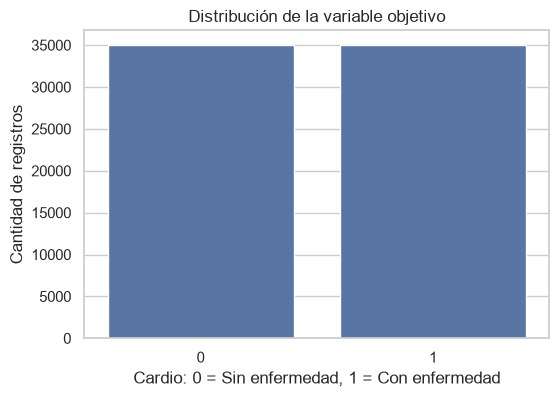

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="cardio")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Cardio: 0 = Sin enfermedad, 1 = Con enfermedad")
plt.ylabel("Cantidad de registros")
plt.show()

In [12]:
# Frecuencia porcentual de la variable objetivo
target_percentages = df["cardio"].value_counts(normalize=True).sort_index() * 100
target_percentages

cardio
0   50.03
1   49.97
Name: proportion, dtype: float64

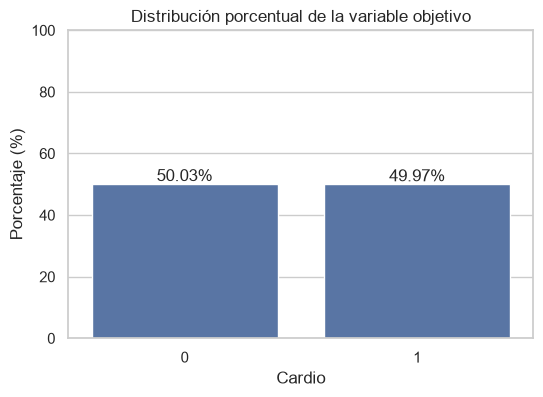

In [13]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=target_percentages.index,
    y=target_percentages.values
)

plt.title("Distribución porcentual de la variable objetivo")
plt.xlabel("Cardio")
plt.ylabel("Porcentaje (%)")
plt.ylim(0, 100)

for i, value in enumerate(target_percentages.values):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.show()

La variable objetivo `cardio` presenta una distribución balanceada entre las clases 0 y 1.

## Analisis de variables

In [14]:
# Crear copia para el análisis exploratorio excluyendo la columna id
df_eda = df.drop(columns=["id"]).copy()

# Crear edad en años para facilitar la interpretación
df_eda["age_years"] = (df_eda["age"] / 365).astype(int)

# Reordenar columnas para dejar age_years cerca de age
df_eda = df_eda[
    [
        "age", "age_years", "gender", "height", "weight",
        "ap_hi", "ap_lo", "cholesterol", "gluc",
        "smoke", "alco", "active", "cardio"
    ]
]

df_eda.head()

,age,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,50,2,168,62.00,110,80,1,1,0,0,1,0
1,20228,55,1,156,85.00,140,90,3,1,0,0,1,1
2,18857,51,1,165,64.00,130,70,3,1,0,0,0,1
3,17623,48,2,169,82.00,150,100,1,1,0,0,1,1
4,17474,47,1,156,56.00,100,60,1,1,0,0,0,0


In [15]:
# Clasificar variables según su tipo para facilitar el análisis posterior
# Variables numericas continuas o discretas interpretables como medidas
numeric_vars = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

# Variables categoricas, ordinales o binarias
categorical_vars = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

# Variable objetivo
target = "cardio"


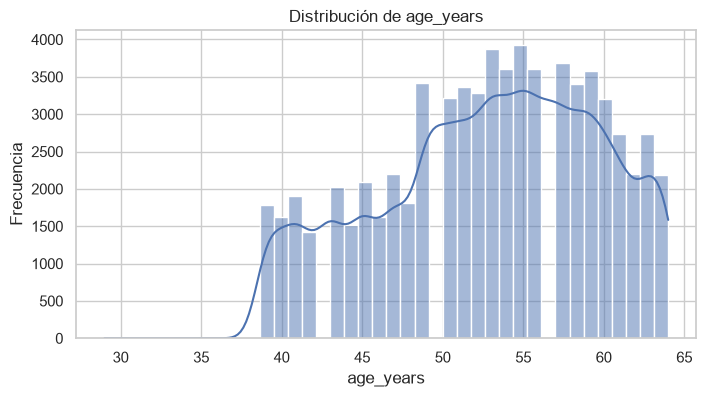

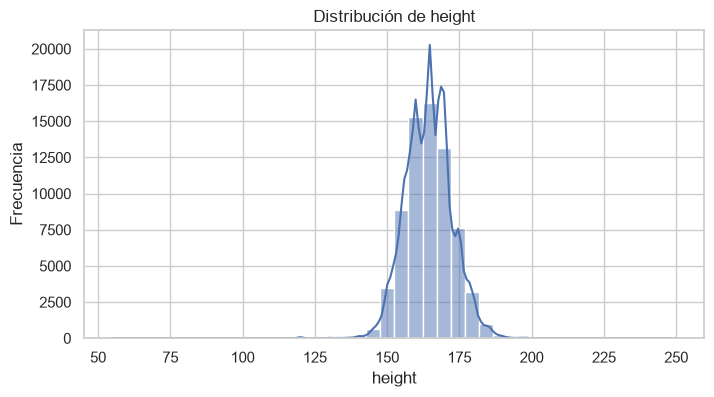

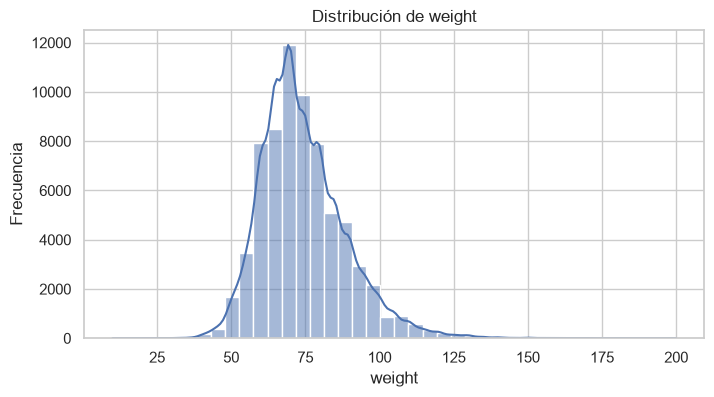

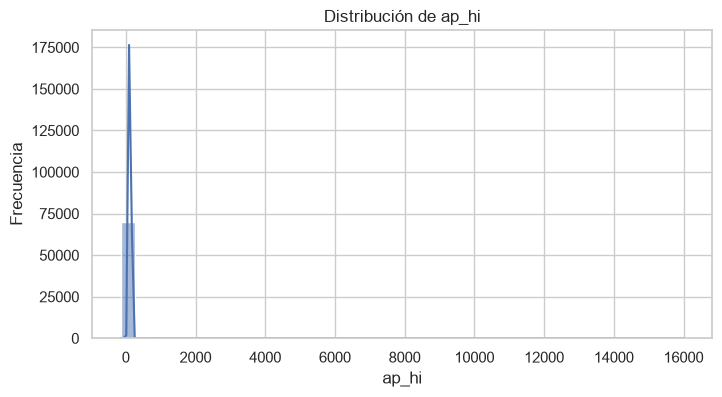

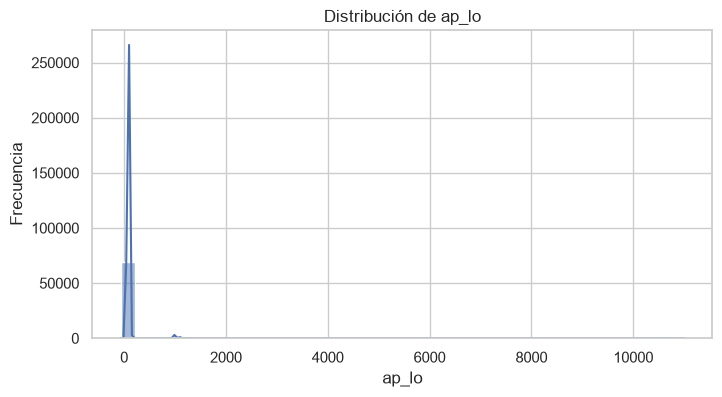

In [16]:
# Histogramas de variables numéricas
for col in numeric_vars:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(data=df_eda, x=col, bins=40, kde=True)
    
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

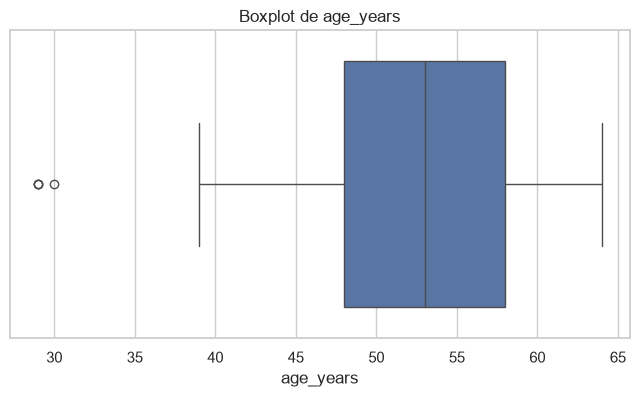

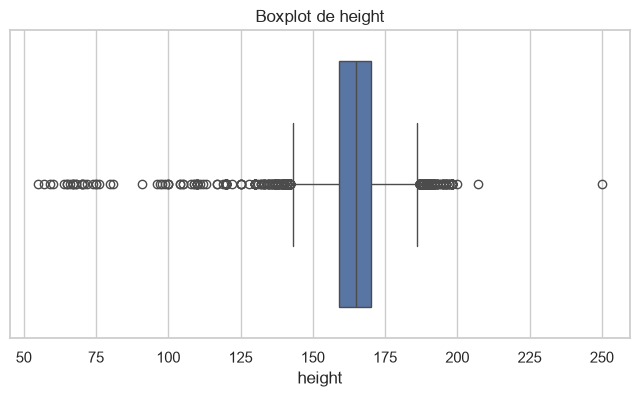

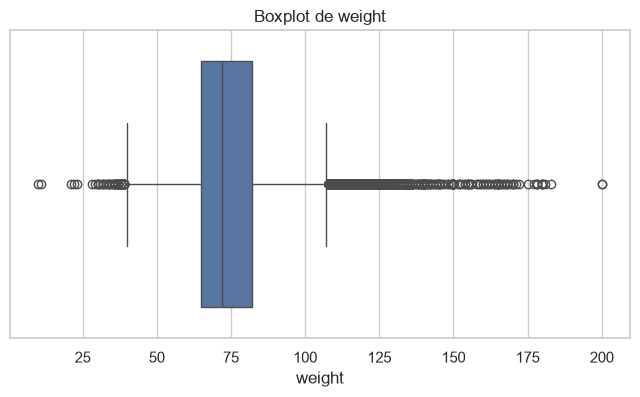

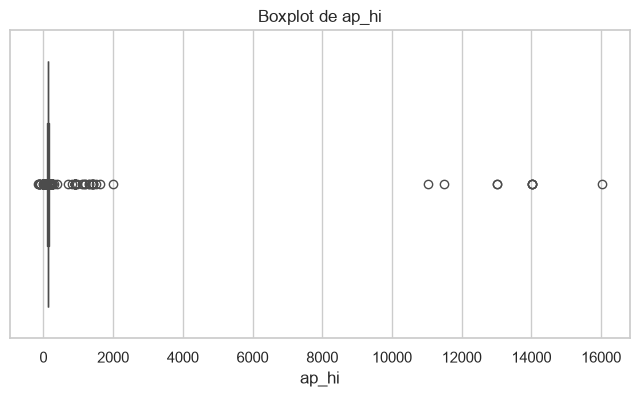

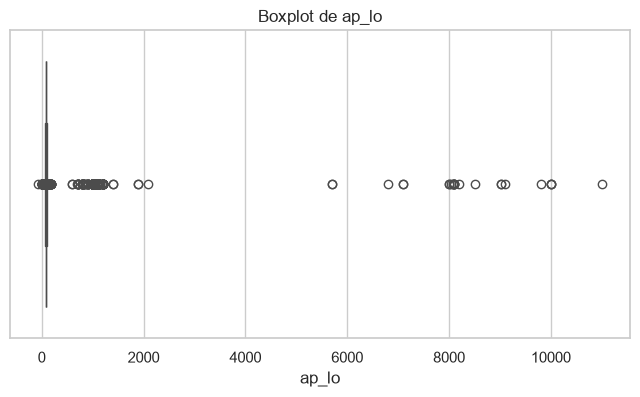

In [17]:
# Boxplots de variables numéricas
for col in numeric_vars:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(data=df_eda, x=col)
    
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

Existen bastantes outliers que se tomaran en cuenta en la limpieza


In [18]:
# Estadísticas descriptivas de variables numéricas
df_eda[numeric_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,70000.00,52.84,6.77,29.00,48.00,53.00,58.00,64.00
height,70000.00,164.36,8.21,55.00,159.00,165.00,170.00,250.00
weight,70000.00,74.21,14.40,10.00,65.00,72.00,82.00,200.00
ap_hi,70000.00,128.82,154.01,-150.00,120.00,120.00,140.00,16020.00
ap_lo,70000.00,96.63,188.47,-70.00,80.00,80.00,90.00,11000.00


Conclusión de boxplots de variables numéricas

Los boxplots muestran que las variables numéricas presentan comportamientos diferentes:

- `age_years`: la mayoría de los registros se concentra aproximadamente entre los 48 y 58 años. Se observan pocos valores bajos cercanos a los 30 años, pero no parecen ser inconsistencias graves.

- `height`: la mayoría de las alturas se concentra alrededor de 160 a 170 cm. Sin embargo, existen valores extremadamente bajos, cercanos a 55 cm, y un valor máximo de 250 cm, lo cual puede representar errores de registro o casos fisiológicamente improbables.

- `weight`: la mayoría de los pesos se encuentra aproximadamente entre 65 y 82 kg. Se observan valores muy bajos, cercanos a 10 kg, y valores altos cercanos a 200 kg. Algunos pueden ser posibles, pero otros requieren revisión.

- `ap_hi`: presenta valores claramente inconsistentes, incluyendo valores negativos y valores extremadamente altos superiores a 10.000. Esto no es fisiológicamente válido para presión arterial sistólica.

- `ap_lo`: también presenta valores inconsistentes, incluyendo valores negativos y valores extremadamente altos superiores a 10.000. Esto indica posibles errores de captura o codificación.

En conclusión, las variables de presión arterial (`ap_hi` y `ap_lo`) son las que presentan mayores inconsistencias. Las variables `height` y `weight` también requieren revisión, pero con criterios cuidadosos para no eliminar información válida. Estos valores no se eliminan en el EDA, pero serán tratados en la etapa de limpieza de datos.

In [19]:
# Conteo de posibles inconsistencias fisiológicas

inconsistencias = {
    "Altura menor a 120 cm": (df_eda["height"] < 120).sum(),
    "Altura mayor a 220 cm": (df_eda["height"] > 220).sum(),
    "Peso menor a 30 kg": (df_eda["weight"] < 30).sum(),
    "Peso mayor a 200 kg": (df_eda["weight"] > 200).sum(),
    "Presión sistólica menor a 80": (df_eda["ap_hi"] < 80).sum(),
    "Presión sistólica mayor a 250": (df_eda["ap_hi"] > 250).sum(),
    "Presión diastólica menor a 40": (df_eda["ap_lo"] < 40).sum(),
    "Presión diastólica mayor a 150": (df_eda["ap_lo"] > 150).sum(),
    "Sistólica menor o igual que diastólica": (df_eda["ap_hi"] <= df_eda["ap_lo"]).sum()
}

inconsistencias_df = pd.DataFrame(
    inconsistencias.items(),
    columns=["Criterio", "Cantidad de registros"]
)

inconsistencias_df["Porcentaje (%)"] = (
    inconsistencias_df["Cantidad de registros"] / len(df_eda)
) * 100

inconsistencias_df

,Criterio,Cantidad de registros,Porcentaje (%)
0,Altura menor a 120 cm,52,0.07
1,Altura mayor a 220 cm,1,0.00
2,Peso menor a 30 kg,7,0.01
3,Peso mayor a 200 kg,0,0.00
4,Presión sistólica menor a 80,207,0.30
5,Presión sistólica mayor a 250,40,0.06
6,Presión diastólica menor a 40,59,0.08
7,Presión diastólica mayor a 150,975,1.39
8,Sistólica menor o igual que diastólica,1236,1.77


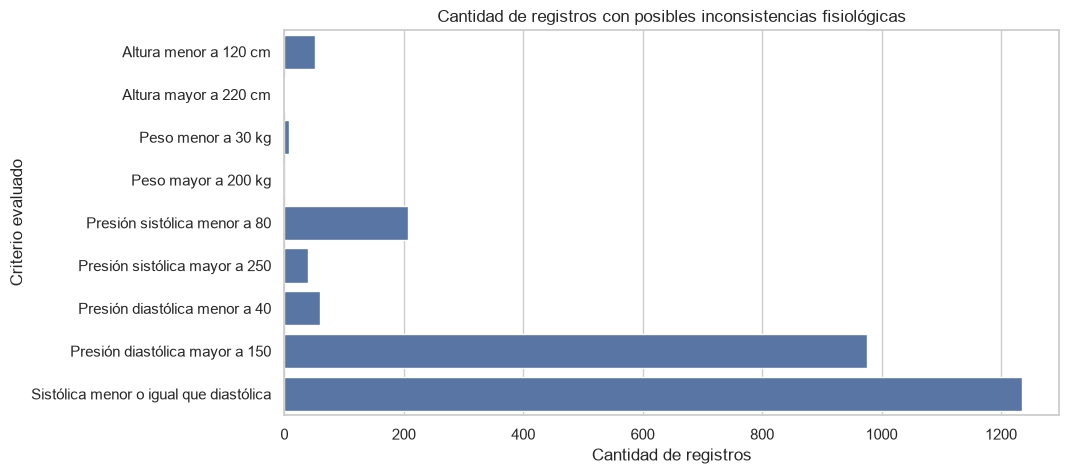

In [20]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=inconsistencias_df,
    x="Cantidad de registros",
    y="Criterio"
)

plt.title("Cantidad de registros con posibles inconsistencias fisiológicas")
plt.xlabel("Cantidad de registros")
plt.ylabel("Criterio evaluado")
plt.show()

## Interpretación de variables categóricas, ordinales y binarias

Aunque estas variables están codificadas numéricamente, representan categorías o respuestas específicas. Por eso, sus valores deben interpretarse de la siguiente manera:

| Variable | Tipo | Valor | Significado |
|---|---|---:|---|
| `gender` | Categórica nominal | 1 | Mujer-Género codificado como categoría 1 |
| `gender` | Categórica nominal | 2 | Hombre-Género codificado como categoría 2 |
| `cholesterol` | Ordinal | 1 | Colesterol normal |
| `cholesterol` | Ordinal | 2 | Colesterol por encima de lo normal |
| `cholesterol` | Ordinal | 3 | Colesterol muy por encima de lo normal |
| `gluc` | Ordinal | 1 | Glucosa normal |
| `gluc` | Ordinal | 2 | Glucosa por encima de lo normal |
| `gluc` | Ordinal | 3 | Glucosa muy por encima de lo normal |
| `smoke` | Binaria | 0 | No fuma |
| `smoke` | Binaria | 1 | Fuma |
| `alco` | Binaria | 0 | No consume alcohol |
| `alco` | Binaria | 1 | Consume alcohol |
| `active` | Binaria | 0 | No realiza actividad física |
| `active` | Binaria | 1 | Realiza actividad física |
| `cardio` | Binaria / objetivo | 0 | No presenta enfermedad cardiovascular |
| `cardio` | Binaria / objetivo | 1 | Presenta enfermedad cardiovascular |

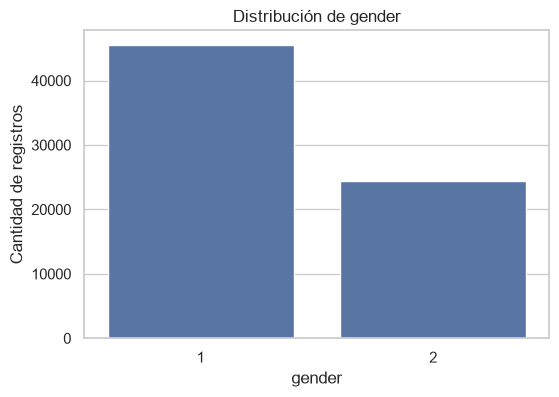

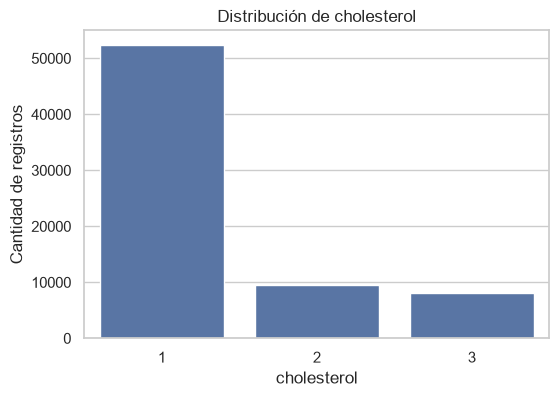

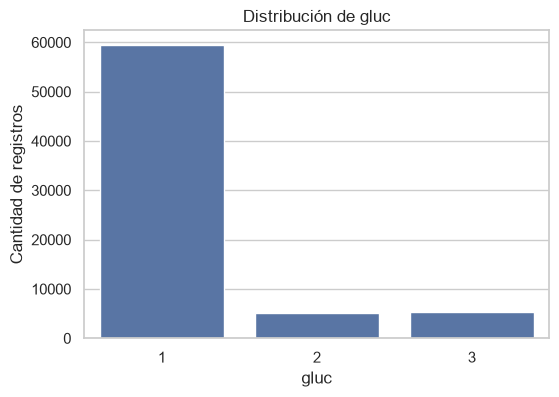

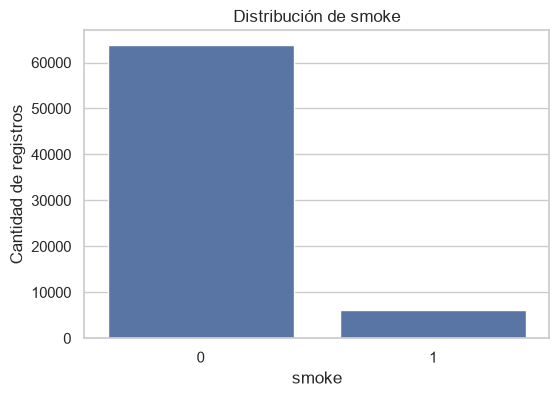

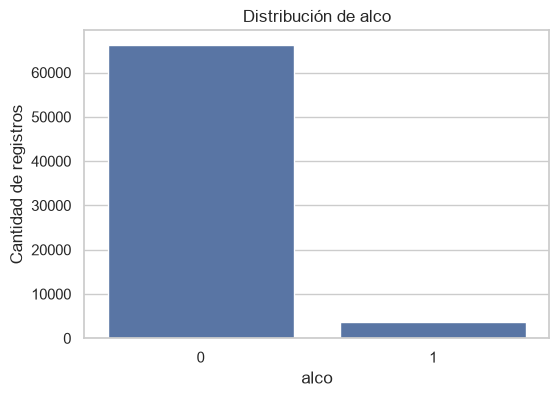

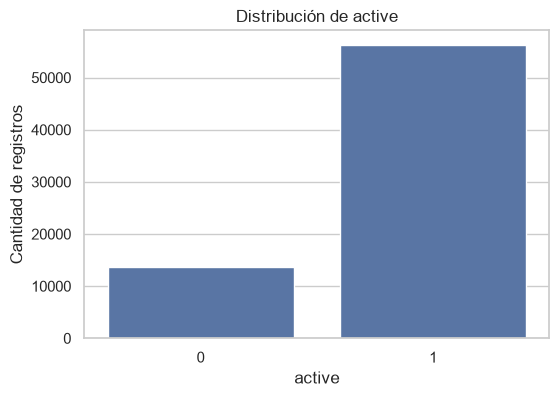

In [21]:
# Distribución de variables categóricas, ordinales y binarias
for col in categorical_vars:
    plt.figure(figsize=(6, 4))
    
    sns.countplot(data=df_eda, x=col)
    
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Cantidad de registros")
    plt.show()

In [22]:
# Frecuencias absolutas y porcentuales de variables categóricas/binarias
for col in categorical_vars:
    freq_table = pd.DataFrame({
        "Frecuencia": df_eda[col].value_counts().sort_index(),
        "Porcentaje (%)": df_eda[col].value_counts(normalize=True).sort_index() * 100
    })
    
    print(f"\nVariable: {col}")
    display(freq_table)


Variable: gender


,Frecuencia,Porcentaje (%)
gender,,
1,45530,65.04
2,24470,34.96



Variable: cholesterol


,Frecuencia,Porcentaje (%)
cholesterol,,
1,52385,74.84
2,9549,13.64
3,8066,11.52



Variable: gluc


...

,Frecuencia,Porcentaje (%)
smoke,,
0,63831,91.19
1,6169,8.81



Variable: alco


,Frecuencia,Porcentaje (%)
alco,,
0,66236,94.62
1,3764,5.38



Variable: active


,Frecuencia,Porcentaje (%)
active,,
0,13739,19.63
1,56261,80.37


In [23]:
# Tabla de frecuencia de la variable objetivo
target_summary = pd.DataFrame({
    "Frecuencia": df_eda["cardio"].value_counts().sort_index(),
    "Porcentaje (%)": df_eda["cardio"].value_counts(normalize=True).sort_index() * 100
})

target_summary

,Frecuencia,Porcentaje (%)
cardio,,
0,35021,50.03
1,34979,49.97


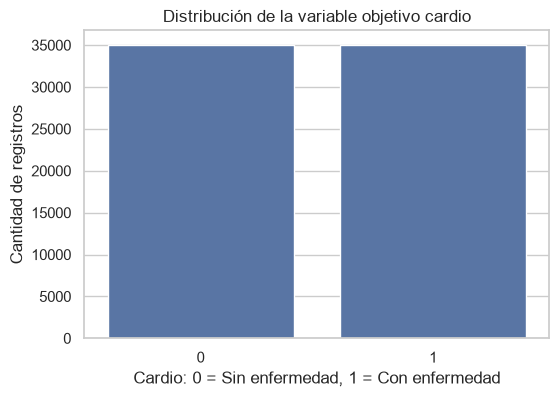

In [24]:
# Gráfico de la variable objetivo
plt.figure(figsize=(6, 4))

sns.countplot(data=df_eda, x="cardio")

plt.title("Distribución de la variable objetivo cardio")
plt.xlabel("Cardio: 0 = Sin enfermedad, 1 = Con enfermedad")
plt.ylabel("Cantidad de registros")
plt.show()

## Analisis bivariado 

In [25]:
# Variables numéricas para análisis bivariado
numeric_vars = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

numeric_vars

['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']

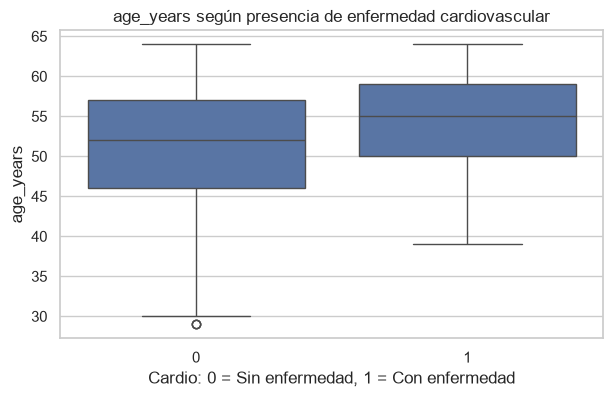

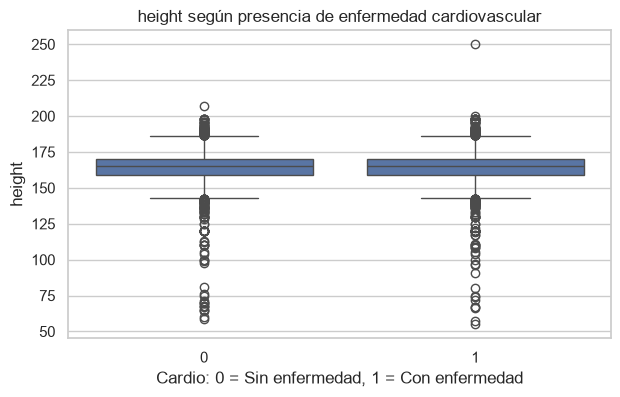

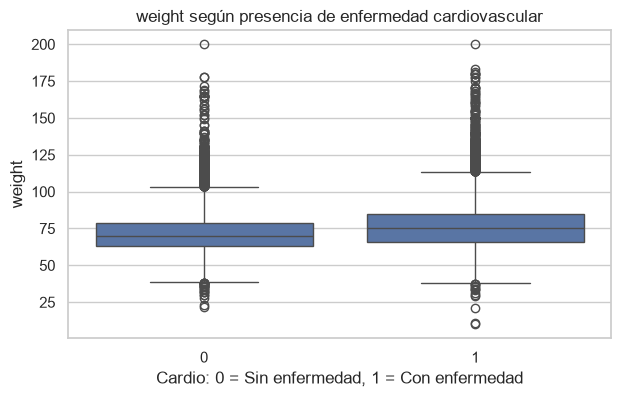

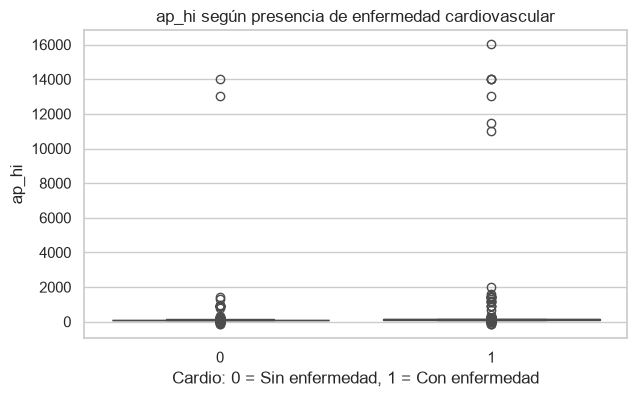

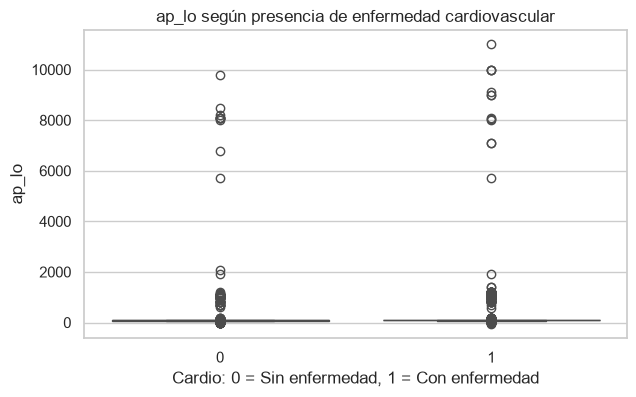

In [26]:
for col in numeric_vars:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(data=df_eda, x="cardio", y=col)
    
    plt.title(f"{col} según presencia de enfermedad cardiovascular")
    plt.xlabel("Cardio: 0 = Sin enfermedad, 1 = Con enfermedad")
    plt.ylabel(col)
    plt.show()

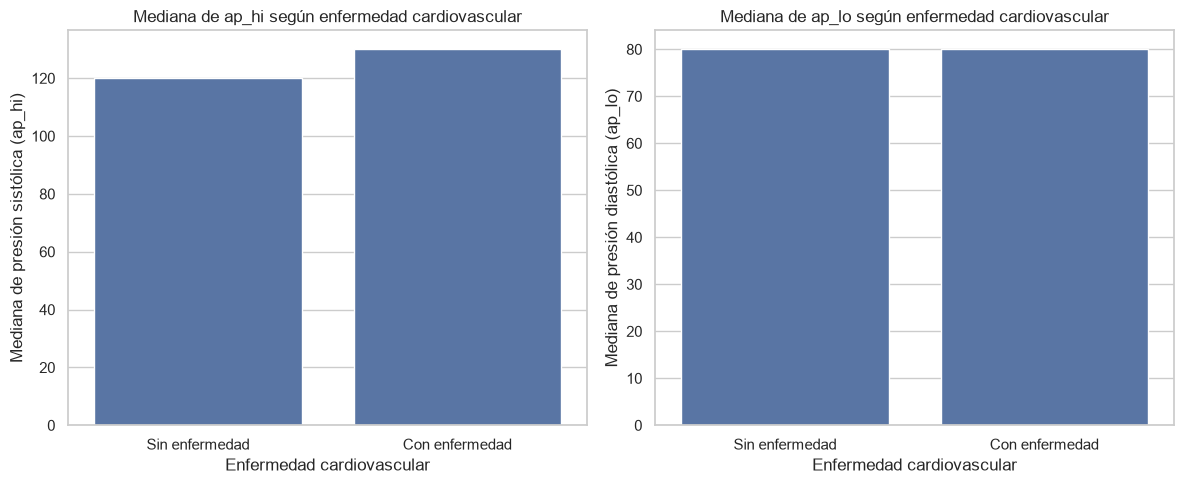

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Relación entre presión arterial y enfermedad cardiovascular usando barras con mediana
plt.figure(figsize=(12, 5))

# ap_hi
plt.subplot(1, 2, 1)
sns.barplot(
    data=df,
    x='cardio',
    y='ap_hi',
    estimator=np.median,
    errorbar=None
)
plt.title('Mediana de ap_hi según enfermedad cardiovascular')
plt.xlabel('Enfermedad cardiovascular')
plt.ylabel('Mediana de presión sistólica (ap_hi)')
plt.xticks([0, 1], ['Sin enfermedad', 'Con enfermedad'])

# ap_lo
plt.subplot(1, 2, 2)
sns.barplot(
    data=df,
    x='cardio',
    y='ap_lo',
    estimator=np.median,
    errorbar=None
)
plt.title('Mediana de ap_lo según enfermedad cardiovascular')
plt.xlabel('Enfermedad cardiovascular')
plt.ylabel('Mediana de presión diastólica (ap_lo)')
plt.xticks([0, 1], ['Sin enfermedad', 'Con enfermedad'])

plt.tight_layout()
plt.show()

In [28]:
# Promedio de variables numéricas agrupadas por cardio
df_eda.groupby("cardio")[numeric_vars].mean().T

cardio,0,1
age_years,51.23,54.45
height,164.45,164.27
weight,71.59,76.82
ap_hi,120.43,137.21
ap_lo,84.25,109.02


In [29]:
# Mediana de variables numéricas agrupadas por cardio
df_eda.groupby("cardio")[numeric_vars].median().T

cardio,0,1
age_years,52.00,55.00
height,165.00,165.00
weight,70.00,75.00
ap_hi,120.00,130.00
ap_lo,80.00,80.00


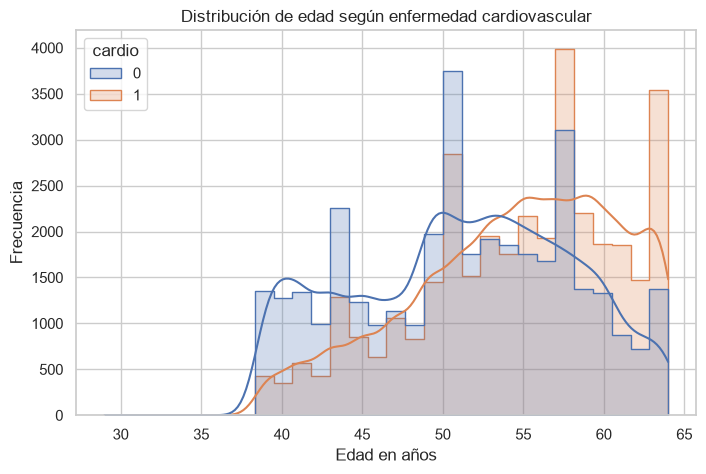

In [30]:
# Edades de los pacientes con y sin enfermedad cardiovascular
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_eda,
    x="age_years",
    hue="cardio",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Distribución de edad según enfermedad cardiovascular")
plt.xlabel("Edad en años")
plt.ylabel("Frecuencia")
plt.show()

### Conclusión del análisis bivariado de variables numéricas

Al comparar las variables numéricas según la variable objetivo `cardio`, se observan diferencias relevantes entre los pacientes con y sin enfermedad cardiovascular.

La edad muestra una diferencia clara: los pacientes con `cardio = 1` tienen una edad promedio y mediana mayor que los pacientes con `cardio = 0`. Esto sugiere que la edad podría ser una variable importante para la predicción.

El peso también presenta valores mayores en el grupo con enfermedad cardiovascular. Esto indica una posible relación entre mayor peso corporal y presencia de enfermedad, aunque en etapas posteriores será más adecuado analizar esta relación mediante una variable derivada como el IMC.

La presión sistólica (`ap_hi`) presenta una mediana mayor en los pacientes con `cardio = 1`, pasando de 120 a 130. Este resultado es coherente con la relación médica entre presión arterial elevada y riesgo cardiovascular.

La presión diastólica (`ap_lo`) muestra una media mayor en el grupo con enfermedad, pero la mediana se mantiene igual entre ambos grupos. Esto indica que la media puede estar afectada por valores extremos, por lo que esta variable debe revisarse cuidadosamente en la etapa de limpieza.

En general, las variables numéricas con mayor señal inicial son `age_years`, `weight` y `ap_hi`. Sin embargo, las variables de presión arterial deben interpretarse con precaución debido a la presencia de valores atípicos e inconsistencias fisiológicas.

In [31]:
# Variables ordinales para análisis bivariado
ordinal_vars = ["cholesterol", "gluc"]

ordinal_vars

['cholesterol', 'gluc']

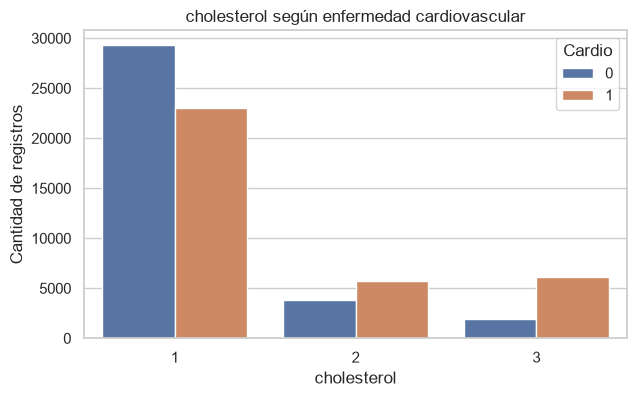

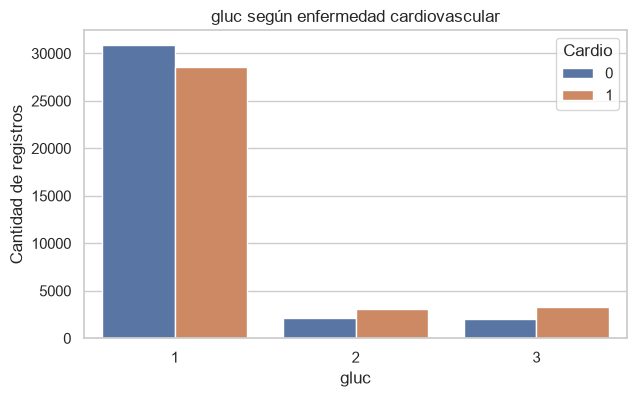

In [32]:
for col in ordinal_vars:
    plt.figure(figsize=(7, 4))
    
    sns.countplot(data=df_eda, x=col, hue="cardio")
    
    plt.title(f"{col} según enfermedad cardiovascular")
    plt.xlabel(col)
    plt.ylabel("Cantidad de registros")
    plt.legend(title="Cardio")
    plt.show()

,cholesterol,Porcentaje con enfermedad cardiovascular
0,1,44.01
1,2,60.22
2,3,76.54


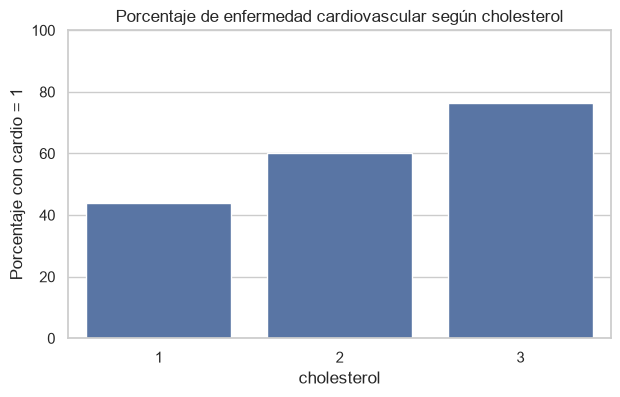

,gluc,Porcentaje con enfermedad cardiovascular
0,1,48.06
1,2,59.31
2,3,62.20


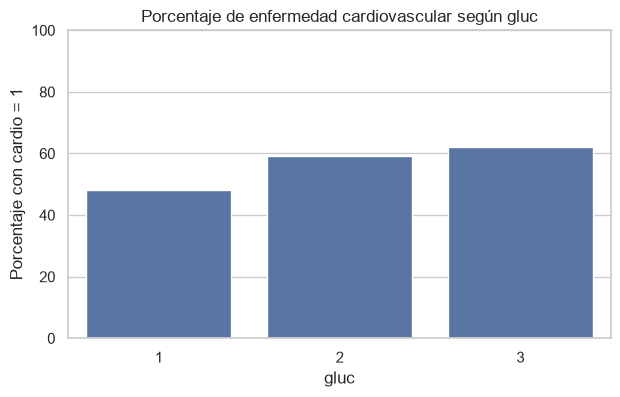

In [33]:
for col in ordinal_vars:
    porcentaje_cardio = (
        df_eda.groupby(col)["cardio"]
        .mean()
        .reset_index()
    )
    
    porcentaje_cardio["Porcentaje con enfermedad cardiovascular"] = porcentaje_cardio["cardio"] * 100
    
    display(porcentaje_cardio[[col, "Porcentaje con enfermedad cardiovascular"]])
    
    plt.figure(figsize=(7, 4))
    
    sns.barplot(
        data=porcentaje_cardio,
        x=col,
        y="Porcentaje con enfermedad cardiovascular"
    )
    
    plt.title(f"Porcentaje de enfermedad cardiovascular según {col}")
    plt.xlabel(col)
    plt.ylabel("Porcentaje con cardio = 1")
    plt.ylim(0, 100)
    plt.show()

In [34]:
# Variables binarias para análisis bivariado
binary_nominal_vars = ["gender", "smoke", "alco", "active"]

binary_nominal_vars

['gender', 'smoke', 'alco', 'active']

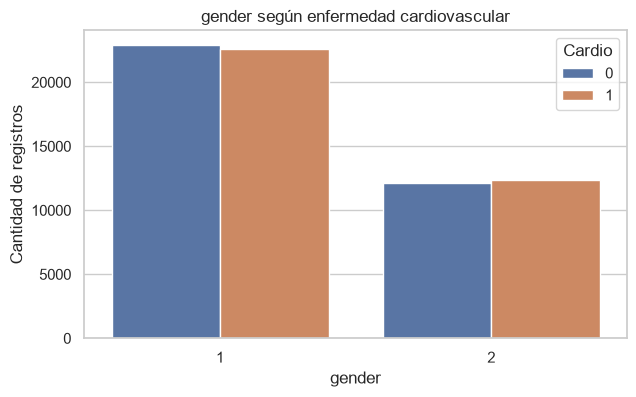

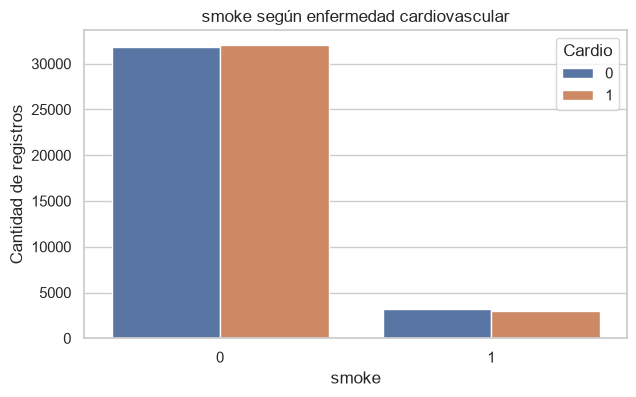

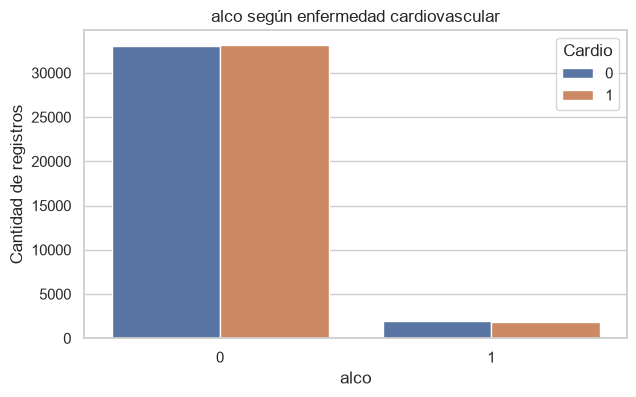

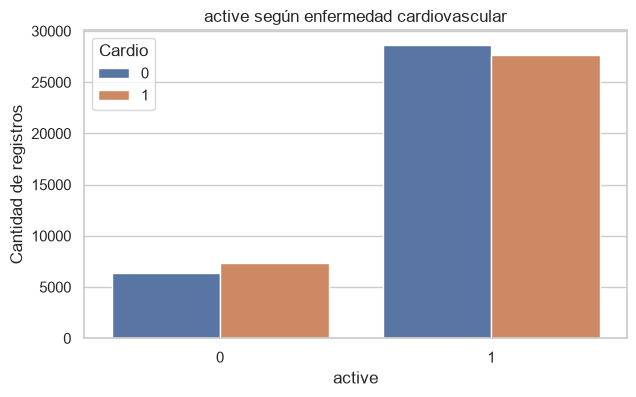

In [35]:
for col in binary_nominal_vars:
    plt.figure(figsize=(7, 4))
    
    sns.countplot(data=df_eda, x=col, hue="cardio")
    
    plt.title(f"{col} según enfermedad cardiovascular")
    plt.xlabel(col)
    plt.ylabel("Cantidad de registros")
    plt.legend(title="Cardio")
    plt.show()

,gender,Porcentaje con enfermedad cardiovascular
0,1,49.67
1,2,50.52


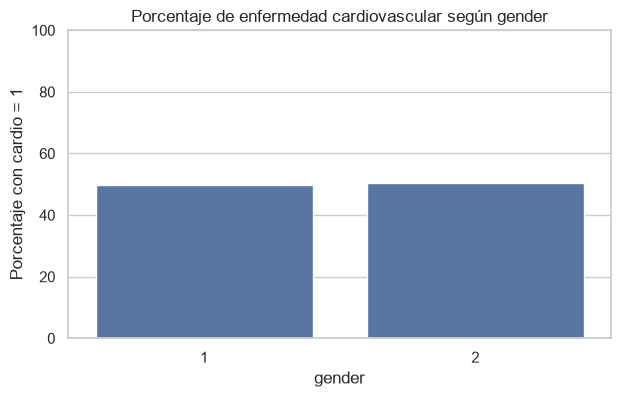

,smoke,Porcentaje con enfermedad cardiovascular
0,0,50.21
1,1,47.48


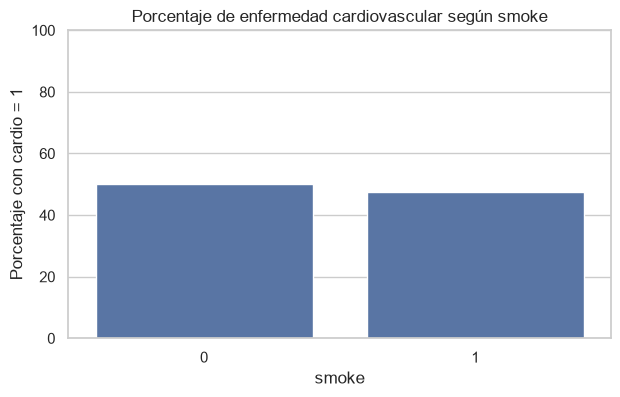

,alco,Porcentaje con enfermedad cardiovascular
0,0,50.06
1,1,48.43


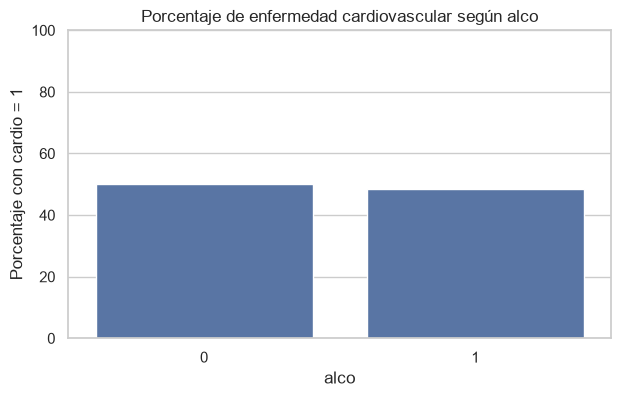

,active,Porcentaje con enfermedad cardiovascular
0,0,53.58
1,1,49.09


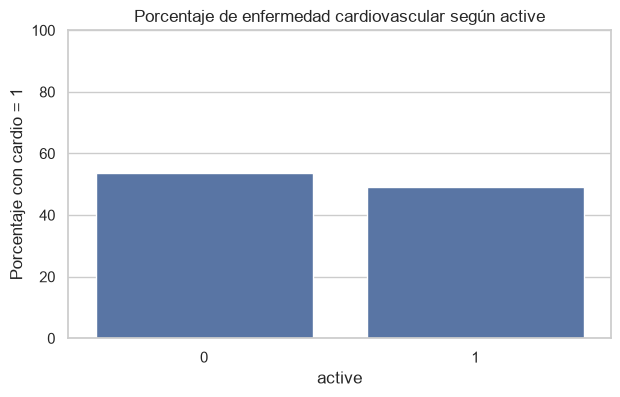

In [36]:
for col in binary_nominal_vars:
    porcentaje_cardio = (
        df_eda.groupby(col)["cardio"]
        .mean()
        .reset_index()
    )
    
    porcentaje_cardio["Porcentaje con enfermedad cardiovascular"] = porcentaje_cardio["cardio"] * 100
    
    display(porcentaje_cardio[[col, "Porcentaje con enfermedad cardiovascular"]])
    
    plt.figure(figsize=(7, 4))
    
    sns.barplot(
        data=porcentaje_cardio,
        x=col,
        y="Porcentaje con enfermedad cardiovascular"
    )
    
    plt.title(f"Porcentaje de enfermedad cardiovascular según {col}")
    plt.xlabel(col)
    plt.ylabel("Porcentaje con cardio = 1")
    plt.ylim(0, 100)
    plt.show()

In [37]:
# Resumen de media de cardio por variables categóricas, ordinales y binarias
cat_analysis_vars = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

for col in cat_analysis_vars:
    resumen = df_eda.groupby(col)["cardio"].agg(
        Cantidad="count",
        Promedio_cardio="mean"
    ).reset_index()
    
    resumen["Porcentaje_cardio_1"] = resumen["Promedio_cardio"] * 100
    
    print(f"\nVariable: {col}")
    display(resumen[[col, "Cantidad", "Porcentaje_cardio_1"]])


Variable: gender


,gender,Cantidad,Porcentaje_cardio_1
0,1,45530,49.67
1,2,24470,50.52



Variable: cholesterol


,cholesterol,Cantidad,Porcentaje_cardio_1
0,1,52385,44.01
1,2,9549,60.22
2,3,8066,76.54



Variable: gluc


...

,smoke,Cantidad,Porcentaje_cardio_1
0,0,63831,50.21
1,1,6169,47.48



Variable: alco


,alco,Cantidad,Porcentaje_cardio_1
0,0,66236,50.06
1,1,3764,48.43



Variable: active


,active,Cantidad,Porcentaje_cardio_1
0,0,13739,53.58
1,1,56261,49.09


### Conclusión del análisis bivariado de variables ordinales y binarias

En las variables ordinales, `cholesterol` muestra una relación clara con la variable objetivo. El porcentaje de personas con enfermedad cardiovascular aumenta conforme sube el nivel de colesterol: 44.01% para colesterol normal, 60.22% para colesterol sobre lo normal y 76.54% para colesterol muy sobre lo normal. Esto sugiere que `cholesterol` es una variable relevante para el modelado.

La variable `gluc` también presenta una tendencia creciente. El porcentaje de enfermedad cardiovascular aumenta de 48.06% en glucosa normal a 59.31% y 62.20% en niveles superiores. Aunque la relación es menos marcada que en colesterol, puede aportar información útil.

En las variables binarias y categóricas, `gender` presenta porcentajes similares entre sus categorías, por lo que no muestra una diferencia fuerte en este análisis inicial. Las variables `smoke` y `alco` tampoco presentan una mayor proporción de enfermedad cardiovascular en los grupos con valor 1. Esto no debe interpretarse como una relación protectora, ya que pueden existir factores de confusión como edad, género u otras variables.

La variable `active` muestra una diferencia moderada: las personas no activas presentan un mayor porcentaje de enfermedad cardiovascular que las personas activas. Esto sugiere que la actividad física podría tener cierta relación con la variable objetivo.

En conjunto, las variables ordinales `cholesterol` y `gluc` muestran señales más claras que las variables binarias. Entre las binarias, `active` parece ser la más informativa en este análisis inicial.

## Análisis de correlaciones

In [38]:
# Crear dataset para correlaciones excluyendo id
df_corr = df_eda.drop(columns=["age"]).copy()

# Verificar columnas utilizadas
df_corr.columns

Index(['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

Se elimina `age` porque la edad ya fue transformada a `age_years`, una variable más interpretable. Además, `id` ya fue excluida previamente porque no aporta información para el análisis.

In [39]:
# Matriz de correlación
correlation_matrix = df_corr.corr(numeric_only=True)

correlation_matrix

,age_years,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age_years,1.00,-0.02,-0.08,0.05,0.02,0.02,0.15,0.10,-0.05,-0.03,-0.01,0.24
gender,-0.02,1.00,0.50,0.16,0.01,0.02,-0.04,-0.02,0.34,0.17,0.01,0.01
height,-0.08,0.50,1.00,0.29,0.01,0.01,-0.05,-0.02,0.19,0.09,-0.01,-0.01
weight,0.05,0.16,0.29,1.00,0.03,0.04,0.14,0.11,0.07,0.07,-0.02,0.18
ap_hi,0.02,0.01,0.01,0.03,1.00,0.02,0.02,0.01,-0.00,0.00,-0.00,0.05
ap_lo,0.02,0.02,0.01,0.04,0.02,1.00,0.02,0.01,0.01,0.01,0.00,0.07
cholesterol,0.15,-0.04,-0.05,0.14,0.02,0.02,1.00,0.45,0.01,0.04,0.01,0.22
gluc,0.10,-0.02,-0.02,0.11,0.01,0.01,0.45,1.00,-0.00,0.01,-0.01,0.09
smoke,-0.05,0.34,0.19,0.07,-0.00,0.01,0.01,-0.00,1.00,0.34,0.03,-0.02
alco,-0.03,0.17,0.09,0.07,0.00,0.01,0.04,0.01,0.34,1.00,0.03,-0.01


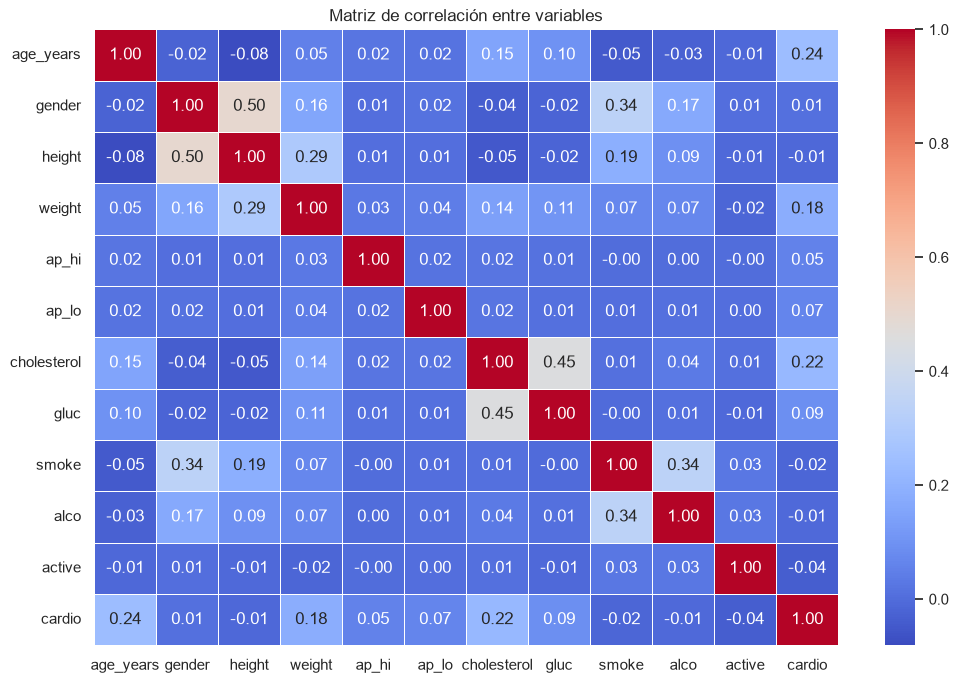

In [40]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables")
plt.show()

In [41]:
# Correlación de cada variable con la variable objetivo cardio
correlation_with_target = (
    correlation_matrix["cardio"]
    .drop("cardio")
    .sort_values(ascending=False)
)

correlation_with_target

age_years      0.24
cholesterol    0.22
weight         0.18
gluc           0.09
ap_lo          0.07
ap_hi          0.05
gender         0.01
alco          -0.01
height        -0.01
smoke         -0.02
active        -0.04
Name: cardio, dtype: float64

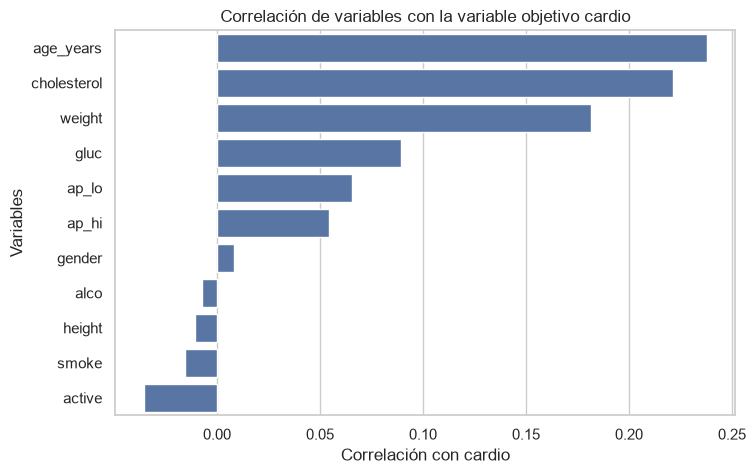

In [42]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=correlation_with_target.values,
    y=correlation_with_target.index
)

plt.title("Correlación de variables con la variable objetivo cardio")
plt.xlabel("Correlación con cardio")
plt.ylabel("Variables")
plt.show()

### Conclusión del análisis de correlaciones

La matriz de correlación muestra que ninguna variable presenta una correlación lineal extremadamente alta con la variable objetivo `cardio`. Esto es esperable en problemas médicos, donde la presencia de enfermedad cardiovascular suele depender de la combinación de varios factores y no de una sola variable.

Las variables con mayor correlación positiva con `cardio` son `age_years`, `cholesterol` y `weight`. Esto coincide con el análisis bivariado, donde se observó que los pacientes con enfermedad cardiovascular tienden a tener mayor edad, mayor peso y niveles más altos de colesterol.

La variable `gluc` también presenta una correlación positiva, aunque más moderada. Esto sugiere que podría aportar información adicional al modelo, especialmente combinada con otras variables clínicas.

Las variables de presión arterial (`ap_hi` y `ap_lo`) muestran correlaciones bajas con `cardio` en esta matriz. Sin embargo, esta interpretación debe realizarse con precaución, ya que ambas variables contienen valores atípicos e inconsistencias fisiológicas que pueden afectar el cálculo de la correlación.

Las variables `smoke`, `alco`, `active`, `height` y `gender` presentan correlaciones muy bajas con la variable objetivo. Esto no significa necesariamente que sean inútiles para el modelado, pero sí indica que, de forma lineal e individual, su relación con `cardio` es débil.

También se observa una correlación relativamente alta entre `cholesterol` y `gluc`, lo que sugiere cierta relación entre variables metabólicas. Además, `gender` se correlaciona con `height`, lo cual puede explicarse por diferencias antropométricas entre las categorías de género.

En conclusión, las correlaciones refuerzan que `age_years`, `cholesterol`, `weight` y `gluc` son variables relevantes para considerar en etapas posteriores. No obstante, antes del modelado será necesario limpiar las variables con valores fisiológicamente inconsistentes y crear variables derivadas como IMC e indicadores de presión arterial.

## Conclusiones generales del EDA



El análisis exploratorio permitió comprender la estructura general del dataset y detectar los principales aspectos que deberán considerarse en las siguientes etapas del proyecto.

En primer lugar, el dataset contiene **70.000 registros** y no presenta valores faltantes ni duplicados exactos. Además, la variable objetivo `cardio` se encuentra prácticamente balanceada, con una proporción cercana al 50% para pacientes con y sin enfermedad cardiovascular. Esto es favorable para el modelado, ya que no se observa un desbalance severo entre clases.

Durante el análisis de variables numéricas se identificaron valores atípicos e inconsistencias fisiológicas, principalmente en las variables `height`, `weight`, `ap_hi` y `ap_lo`. En particular, las variables de presión arterial presentan valores negativos y valores extremadamente altos, lo cual indica posibles errores de registro. Estos casos deberán tratarse en la etapa de limpieza antes de entrenar modelos.

El análisis bivariado mostró que los pacientes con enfermedad cardiovascular tienden a presentar mayor edad, mayor peso y mayores valores de presión sistólica. Sin embargo, las variables de presión arterial deben interpretarse con precaución hasta ser depuradas.

En las variables ordinales, `cholesterol` mostró una relación clara con la variable objetivo: a medida que aumenta el nivel de colesterol, también aumenta el porcentaje de personas con enfermedad cardiovascular. La variable `gluc` también presentó una tendencia creciente, aunque menos marcada.

En las variables binarias, `active` mostró cierta diferencia entre personas activas y no activas, mientras que `smoke` y `alco` no presentaron una relación directa clara en este análisis inicial. Esto no significa que dichas variables no sean importantes desde el punto de vista médico, sino que en este dataset su relación individual con `cardio` puede estar influida por otros factores.

El análisis de correlaciones confirmó que las variables con mayor relación lineal con `cardio` son `age_years`, `cholesterol` y `weight`. También se observó que ninguna variable explica por sí sola la presencia de enfermedad cardiovascular, por lo que será necesario construir modelos que combinen múltiples variables.

En conclusión, el dataset es adecuado para un problema de clasificación supervisada, pero requiere una etapa de limpieza cuidadosa antes del modelado. Las siguientes fases deberán enfocarse en tratar valores fisiológicamente inconsistentes, crear variables derivadas como el IMC y categorías de presión arterial, y preparar los datos para entrenar modelos predictivos.